# PCA Eigen Portfolios

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / 'unsupervised_utils.py').exists():
        sys.path.insert(0, str(parent))
        break

from unsupervised_utils import *

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()


In [2]:
returns = make_asset_returns(seed=135)
weights = eigen_portfolio_weights(returns, component=1)
portfolio = portfolio_backtest(returns, weights)
weights.to_csv(OUTPUT / 'eigen_portfolio_weights.csv')
portfolio.to_parquet(OUTPUT / 'eigen_portfolio_backtest.parquet')
weights.abs().sort_values(ascending=False).head()

Asset_058   0.0307
Asset_017   0.0299
Asset_054   0.0297
Asset_036   0.0295
Asset_012   0.0294
Name: factor_1, dtype: float64

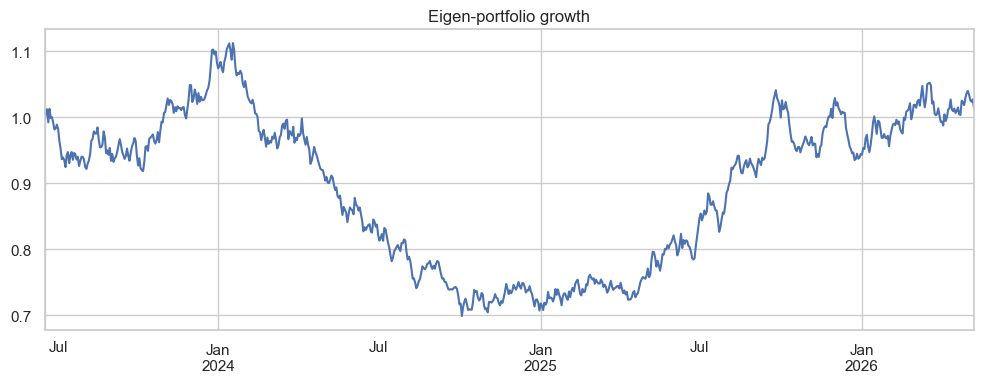

In [3]:
portfolio['equity_curve'].plot(figsize=(10, 4), title='Eigen-portfolio growth')
plt.tight_layout()